# Pre-Modeling Exploratory Analysis

In [17]:
import seaborn as sns
import pandas as pd
import geopandas as gpd
import numpy as np
import dataframe_image as dfi
import matplotlib.pyplot as plt

In [2]:
# setting wd 
import os
os.chdir('/users/bkung/fooddesertproject')

In [48]:
bexar_gdf = gpd.read_file("modeling_data/bexar_modeling_final.gpkg")
travis_gdf = gpd.read_file("modeling_data/travis_modeling_final.gpkg")
harris_gdf = gpd.read_file("modeling_data/harris_modeling_final.gpkg")
dallas_gdf = gpd.read_file("modeling_data/dallas_modeling_final.gpkg")
tarrant_gdf = gpd.read_file("modeling_data/tarrant_modeling_final.gpkg")

In [49]:
bexar_gdf.columns

Index(['COUNTY', 'GEOID', 'tract', 'walking_ind', 'walkind_inv_perc',
       'total_pop', 'total_pop_moe', 'below_200_fed_poverty_percentage',
       'no_hs_diploma', 'uninsured', 'E_CHD', 'E_DIABETES', 'E_AFAM',
       'E_ASIAN', 'E_HISP', 'median_age', 'ALAND', 'AWATER',
       'distance_to_nearest_grocery', 'distance_to_nearest_fm',
       'distance_to_nearest_uf', 'median_income', 'pct_no_vehicle',
       'geometry'],
      dtype='object')

In [5]:
# renaming county column for continuity with other variables 
bexar_gdf['county'] = bexar_gdf['COUNTY'] 
travis_gdf['county'] = travis_gdf['COUNTY'] 
harris_gdf['county'] = harris_gdf['COUNTY'] 
dallas_gdf['county'] = dallas_gdf['COUNTY'] 
tarrant_gdf['county'] = tarrant_gdf['COUNTY']  

In [50]:
# Recoding missing values from CDC-generated variables
columns_to_recode = ["uninsured", "E_CHD", "E_DIABETES"]
bexar_gdf[columns_to_recode] = bexar_gdf[columns_to_recode].replace({-999.00: np.nan})
travis_gdf[columns_to_recode] = travis_gdf[columns_to_recode].replace({-999.00: np.nan})
harris_gdf[columns_to_recode] = harris_gdf[columns_to_recode].replace({-999.00: np.nan})
dallas_gdf[columns_to_recode] = dallas_gdf[columns_to_recode].replace({-999.00: np.nan})
tarrant_gdf[columns_to_recode] = tarrant_gdf[columns_to_recode].replace({-999.00: np.nan})

In [53]:
# generating summary statistics tables for all counties 

columns_subset = ["walking_ind", "total_pop", "uninsured", "E_CHD", "E_DIABETES", 
            "median_age", "distance_to_nearest_grocery", "distance_to_nearest_fm", 
                  "distance_to_nearest_uf", "median_income", "pct_no_vehicle"]

bexar_summary = bexar_gdf[columns_subset].describe().T
bexar_sum_table = (
    bexar_summary.style.set_caption("<b>Bexar County Summary Statistics</b>")
    .format(formatter="{:,.2f}")
    .set_properties(**{"font-family": "Segoe UI", "font-size": "13px"})
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#f4f4f4")]}]
    )
)
dfi.export(bexar_sum_table, "Stat_Modeling/bexar_summary_stats.png", table_conversion="matplotlib")

travis_summary = travis_gdf[columns_subset].describe().T
travis_sum_table = (
    travis_summary.style.set_caption("<b>Travis County Summary Statistics</b>")
    .format(formatter="{:,.2f}")
    .set_properties(**{"font-family": "Segoe UI", "font-size": "13px"})
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#f4f4f4")]}]
    )
)
dfi.export(travis_sum_table, "Stat_Modeling/travis_summary_stats.png", table_conversion="matplotlib")

harris_summary = harris_gdf[columns_subset].describe().T
harris_sum_table = (
    harris_summary.style.set_caption("<b>Harris County Summary Statistics</b>")
    .format(formatter="{:,.2f}")
    .set_properties(**{"font-family": "Segoe UI", "font-size": "13px"})
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#f4f4f4")]}]
    )
)
dfi.export(harris_sum_table, "Stat_Modeling/harris_summary_stats.png", table_conversion="matplotlib")

dallas_summary = dallas_gdf[columns_subset].describe().T
dallas_sum_table = (
    dallas_summary.style.set_caption("<b>Dallas County Summary Statistics</b>")
    .format(formatter="{:,.2f}")
    .set_properties(**{"font-family": "Segoe UI", "font-size": "13px"})
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#f4f4f4")]}]
    )
)
dfi.export(dallas_sum_table, "Stat_Modeling/dallas_summary_stats.png", table_conversion="matplotlib")

tarrant_summary = tarrant_gdf[columns_subset].describe().T
tarrant_sum_table = (
    tarrant_summary.style.set_caption("<b>Tarrant County Summary Statistics</b>")
    .format(formatter="{:,.2f}")
    .set_properties(**{"font-family": "Segoe UI", "font-size": "13px"})
    .set_table_styles(
        [{"selector": "th", "props": [("background-color", "#f4f4f4")]}]
    )
)
dfi.export(tarrant_sum_table, "Stat_Modeling/tarrant_summary_stats.png", table_conversion="matplotlib")

Note: median income seems to be top-coded at 250,000, which could be an issue for the modeling. 

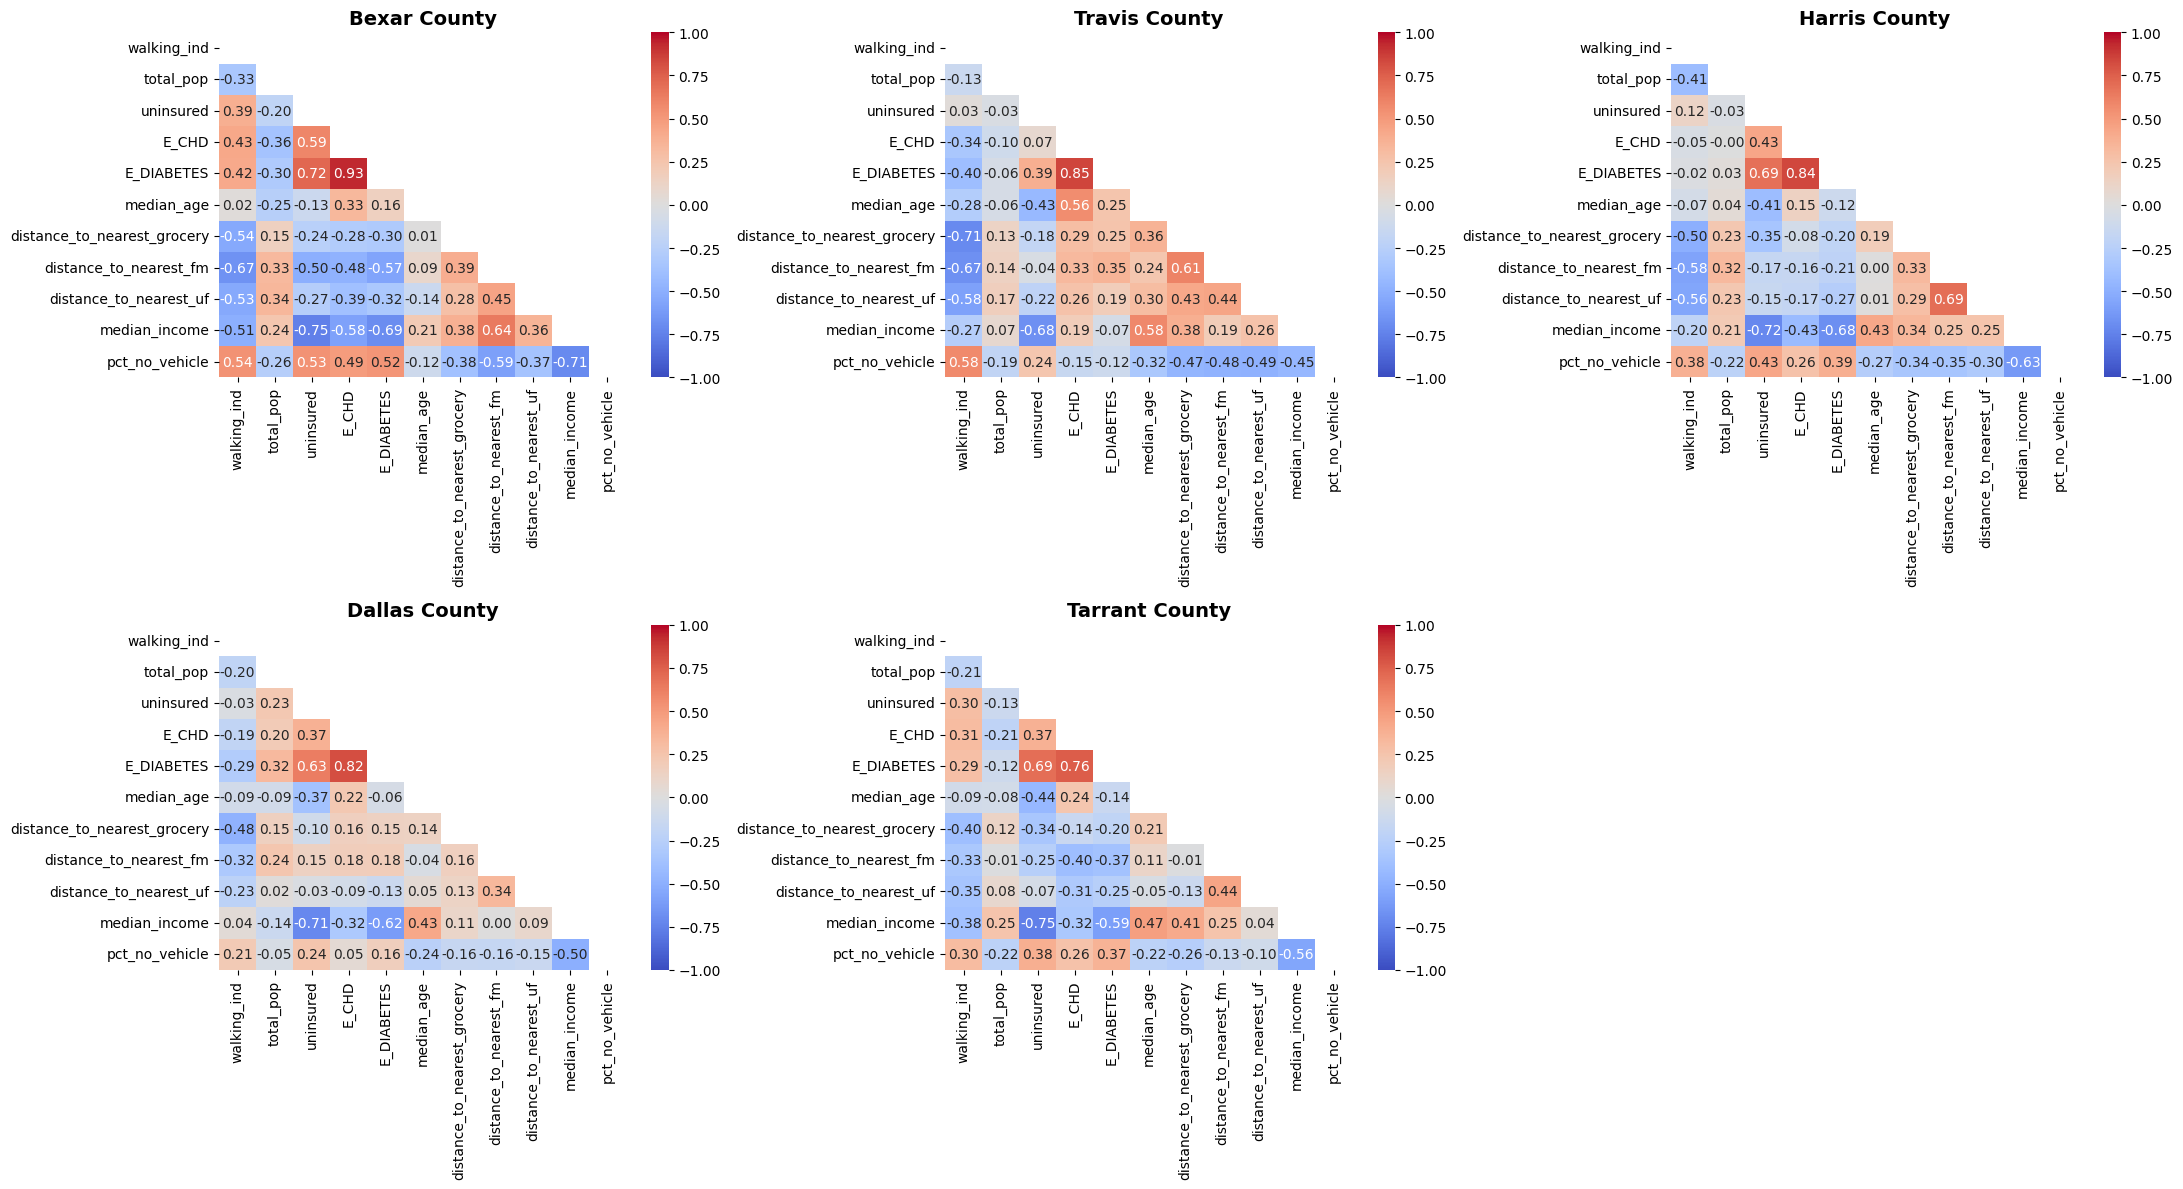

In [54]:
# GENERATING SPEARMAN CORRELATIONS FOR ALL COUNTIES IN ALL RELEVANT VARIABLES

# setting dataframes and titles to loop through
dfs = [bexar_gdf[columns_subset], travis_gdf[columns_subset], harris_gdf[columns_subset], dallas_gdf[columns_subset], tarrant_gdf[columns_subset]]
title_names = ["Bexar County", "Travis County", "Harris County", "Dallas County", "Tarrant County"]

# initializing canvas
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

# looping through each dataset 
for i, df in enumerate(dfs):
    # calculating matrix 
    matrix = df.corr(method="spearman")
    # masking the upper triangle to avoid redundancy 
    mask = np.triu(np.ones_like(matrix, dtype=bool))
    # setting the current axis 
    current_ax = axes[i]
    # generating heatmap
    sns.heatmap(
        matrix,
        mask=mask,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        ax=current_ax,
        cbar=True,
        fmt=".2f",  
    )
    # setting title for each axis 
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
# removing content in empty axis 
fig.delaxes(axes[5])
fig.tight_layout()
plt.savefig("Stat_Modeling/Spearman_correlation_matrices.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

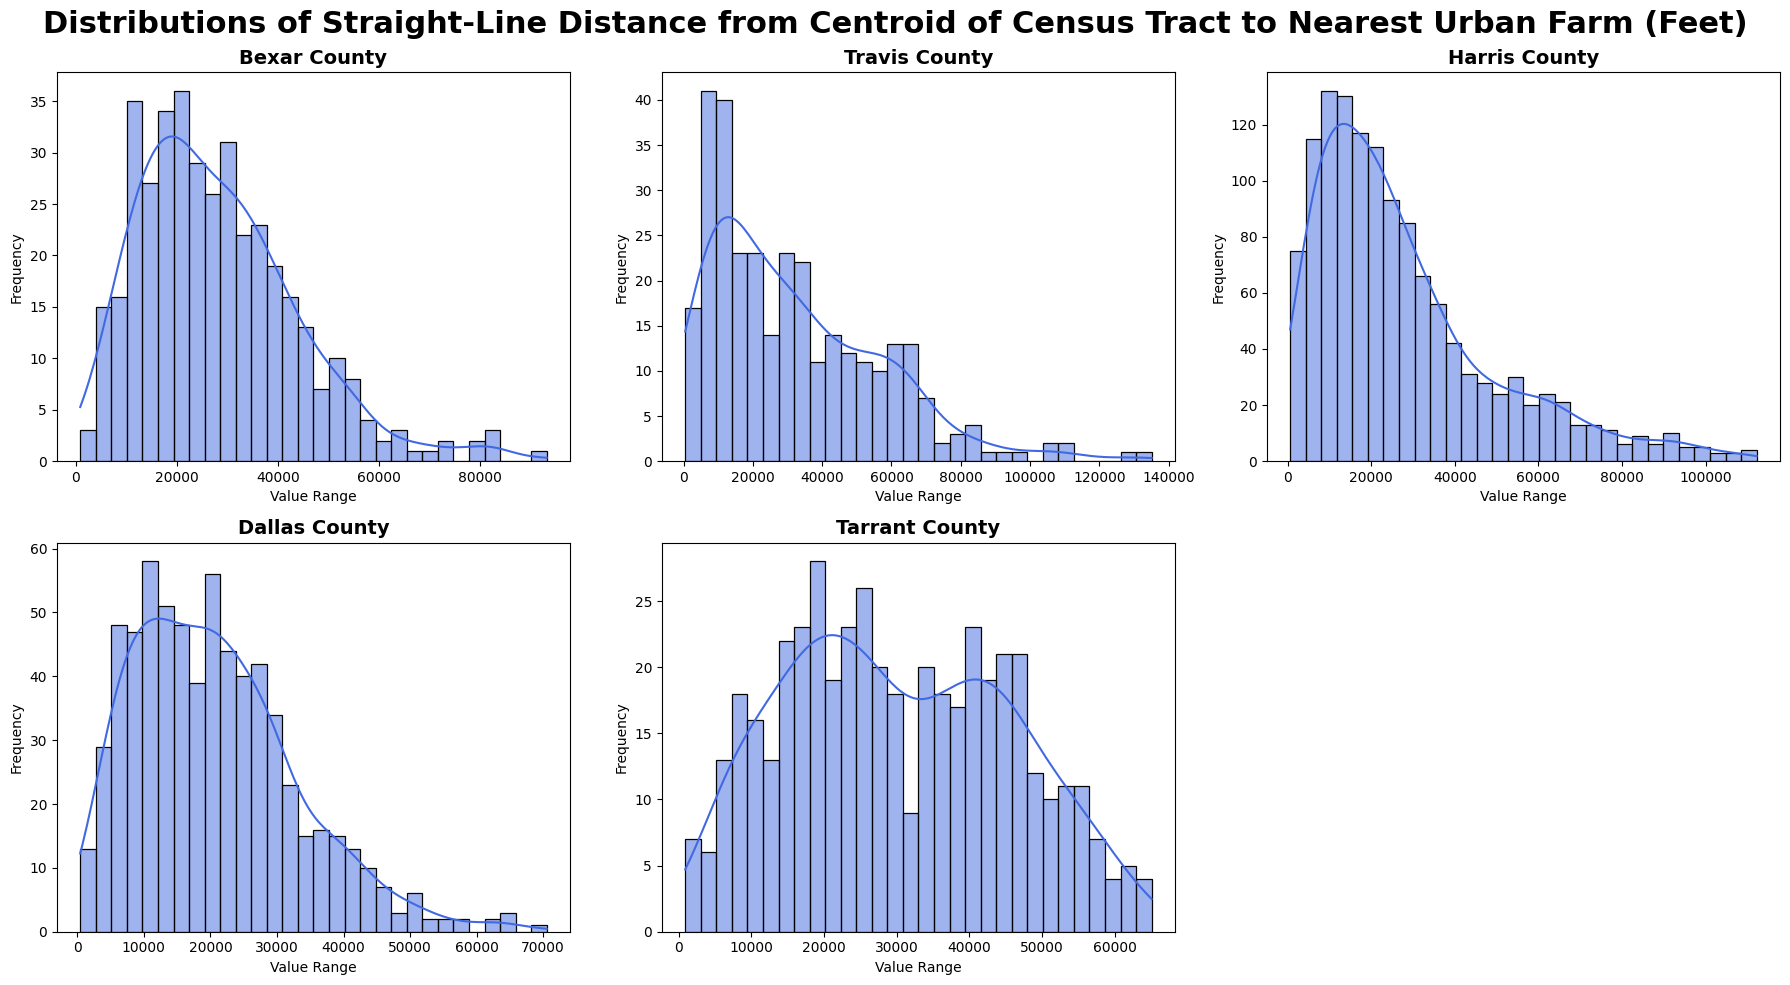

In [57]:
# GENERATING HISTOGRAMS OF DISTANCES TO URBAN FARMS
# 1. Define custom title names for your 5 histogram plots
title_names = [
    "Bexar County",
    "Travis County",
    "Harris County",
    "Dallas County",
    "Tarrant County",
]
dfs = [bexar_gdf, travis_gdf, harris_gdf, 
       dallas_gdf, tarrant_gdf]


# 2. Set up the 2-row, 3-column grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten to easily index ax1 through ax6

# 3. Loop and plot a histogram on each axis
for i, df in enumerate(dfs):
    current_ax = axes[i]

    # Draw the histogram with an optional smooth KDE density curve
    sns.histplot(
        data=df,
        x="distance_to_nearest_uf",
        kde=True,  # Adds a kernel density estimate line
        color="royalblue",  # Bar color
        bins=30,  # Number of bins
        ax=current_ax,
    )

    # Apply your custom title and clean up axis labels
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
    current_ax.set_xlabel("Value Range")
    current_ax.set_ylabel("Frequency")

# 4. Delete the empty 6th slot so the layout is clean
fig.delaxes(axes[5])

fig.suptitle(
    "Distributions of Straight-Line Distance from Centroid of Census Tract to Nearest Urban Farm (Feet)",  # Your main title text
    fontsize=22,  
    fontweight="bold",  
    y=0.98,  
)

# 5. Fix spacing layout and export cleanly to prevent overlapping
fig.tight_layout()
plt.savefig("Stat_Modeling/nearest_uf_dist_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


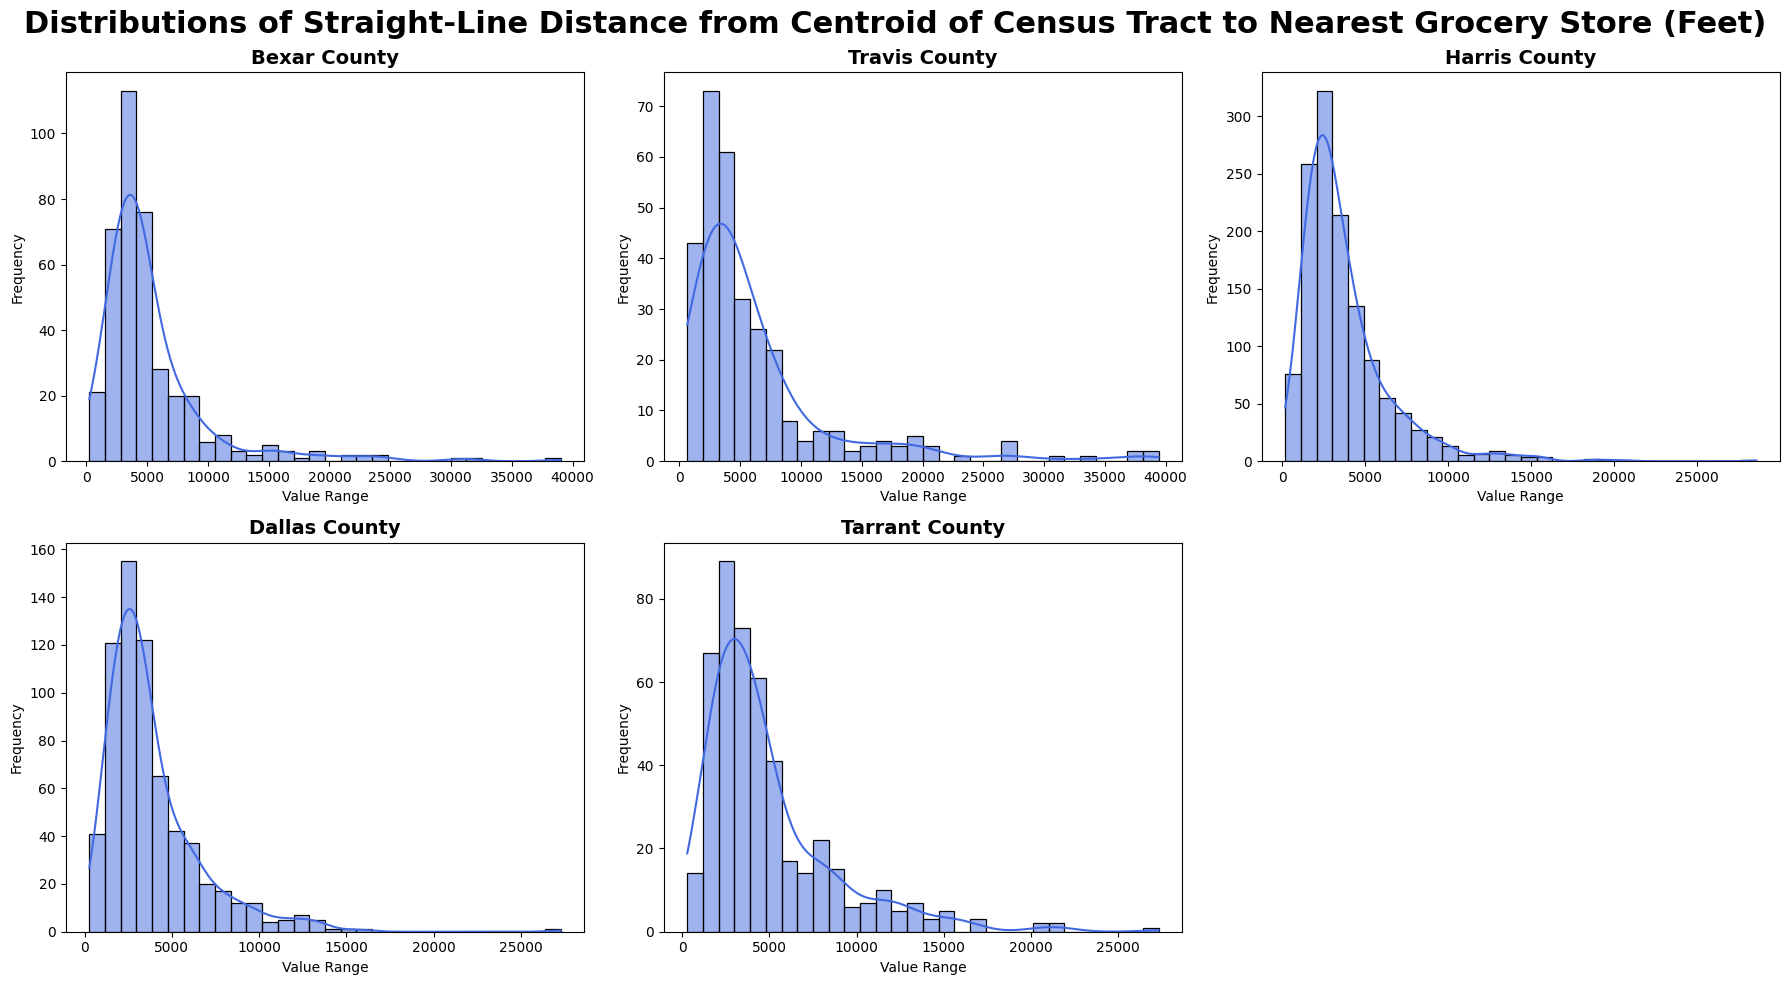

In [58]:
# GENERATING HISTOGRAMS OF DISTANCES TO GROCERY STORES 
# 1. Define custom title names for your 5 histogram plots
title_names = [
    "Bexar County",
    "Travis County",
    "Harris County",
    "Dallas County",
    "Tarrant County",
]
dfs = [bexar_gdf, travis_gdf, harris_gdf, 
       dallas_gdf, tarrant_gdf]


# 2. Set up the 2-row, 3-column grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten to easily index ax1 through ax6

# 3. Loop and plot a histogram on each axis
for i, df in enumerate(dfs):
    current_ax = axes[i]

    # Draw the histogram with an optional smooth KDE density curve
    sns.histplot(
        data=df,
        x="distance_to_nearest_grocery",
        kde=True,  # Adds a kernel density estimate line
        color="royalblue",  # Bar color
        bins=30,  # Number of bins
        ax=current_ax,
    )

    # Apply your custom title and clean up axis labels
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
    current_ax.set_xlabel("Value Range")
    current_ax.set_ylabel("Frequency")

# 4. Delete the empty 6th slot so the layout is clean
fig.delaxes(axes[5])

fig.suptitle(
    "Distributions of Straight-Line Distance from Centroid of Census Tract to Nearest Grocery Store (Feet)",  # Your main title text
    fontsize=22,  
    fontweight="bold",  
    y=0.98,  
)

# 5. Fix spacing layout and export cleanly to prevent overlapping
fig.tight_layout()
plt.savefig("Stat_Modeling/nearest_grocery_dist_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


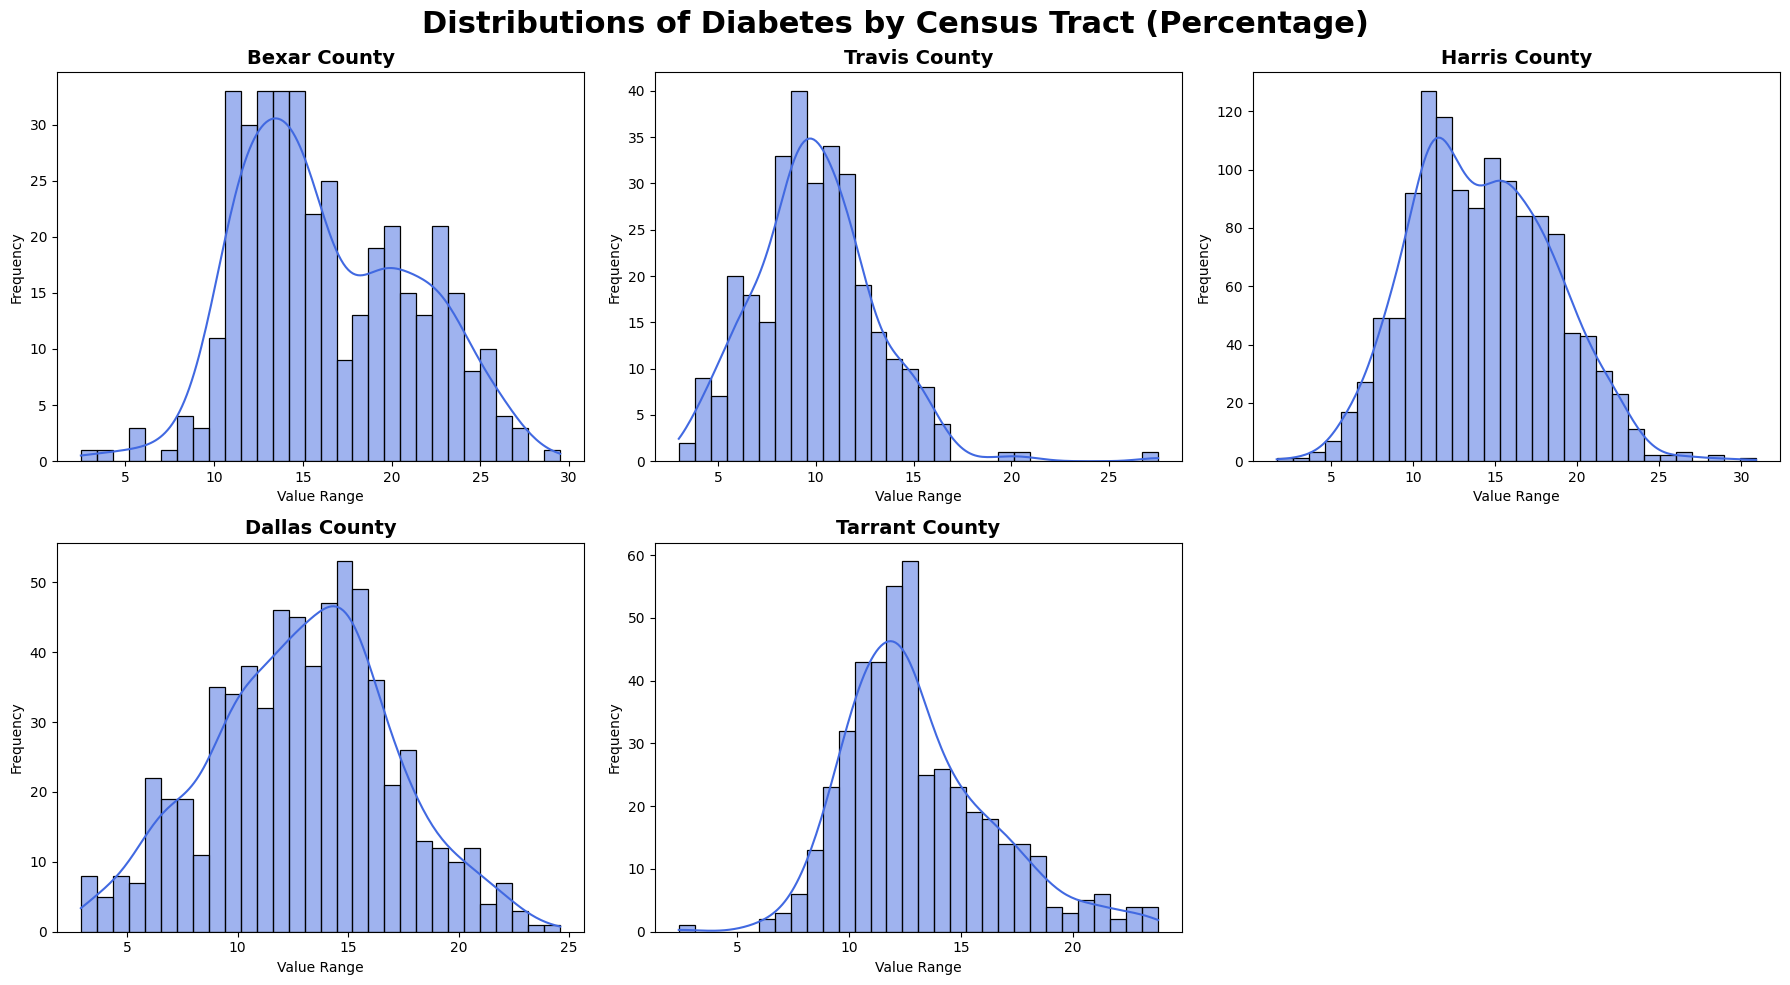

In [55]:
# GENERATING HISTOGRAMS OF DIABETES 
# defining title names and dataframes to loop through 
title_names = [
    "Bexar County",
    "Travis County",
    "Harris County",
    "Dallas County",
    "Tarrant County",
]
dfs = [bexar_gdf, travis_gdf, harris_gdf, 
       dallas_gdf, tarrant_gdf]

# initializing canvas 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten to easily index ax1 through ax6

# looping through and plotting histograms 
for i, df in enumerate(dfs):
    current_ax = axes[i]
    
    # generating histogram
    sns.histplot(
        data=df,
        x="E_DIABETES",
        kde=True,  # Adds a kernel density estimate line
        color="royalblue",  # Bar color
        bins=30,  # Number of bins
        ax=current_ax,
    )

    # applying axes and histogram titles 
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
    current_ax.set_xlabel("Value Range")
    current_ax.set_ylabel("Frequency")

# removing content in empty axis 
fig.delaxes(axes[5])

# setting overarching title
fig.suptitle(
    "Distributions of Diabetes by Census Tract (Percentage)",  
    fontsize=22,  
    fontweight="bold",  
    y=0.98,  
)
# saving and fixing layout 
fig.tight_layout()
plt.savefig("Stat_Modeling/diabetes_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

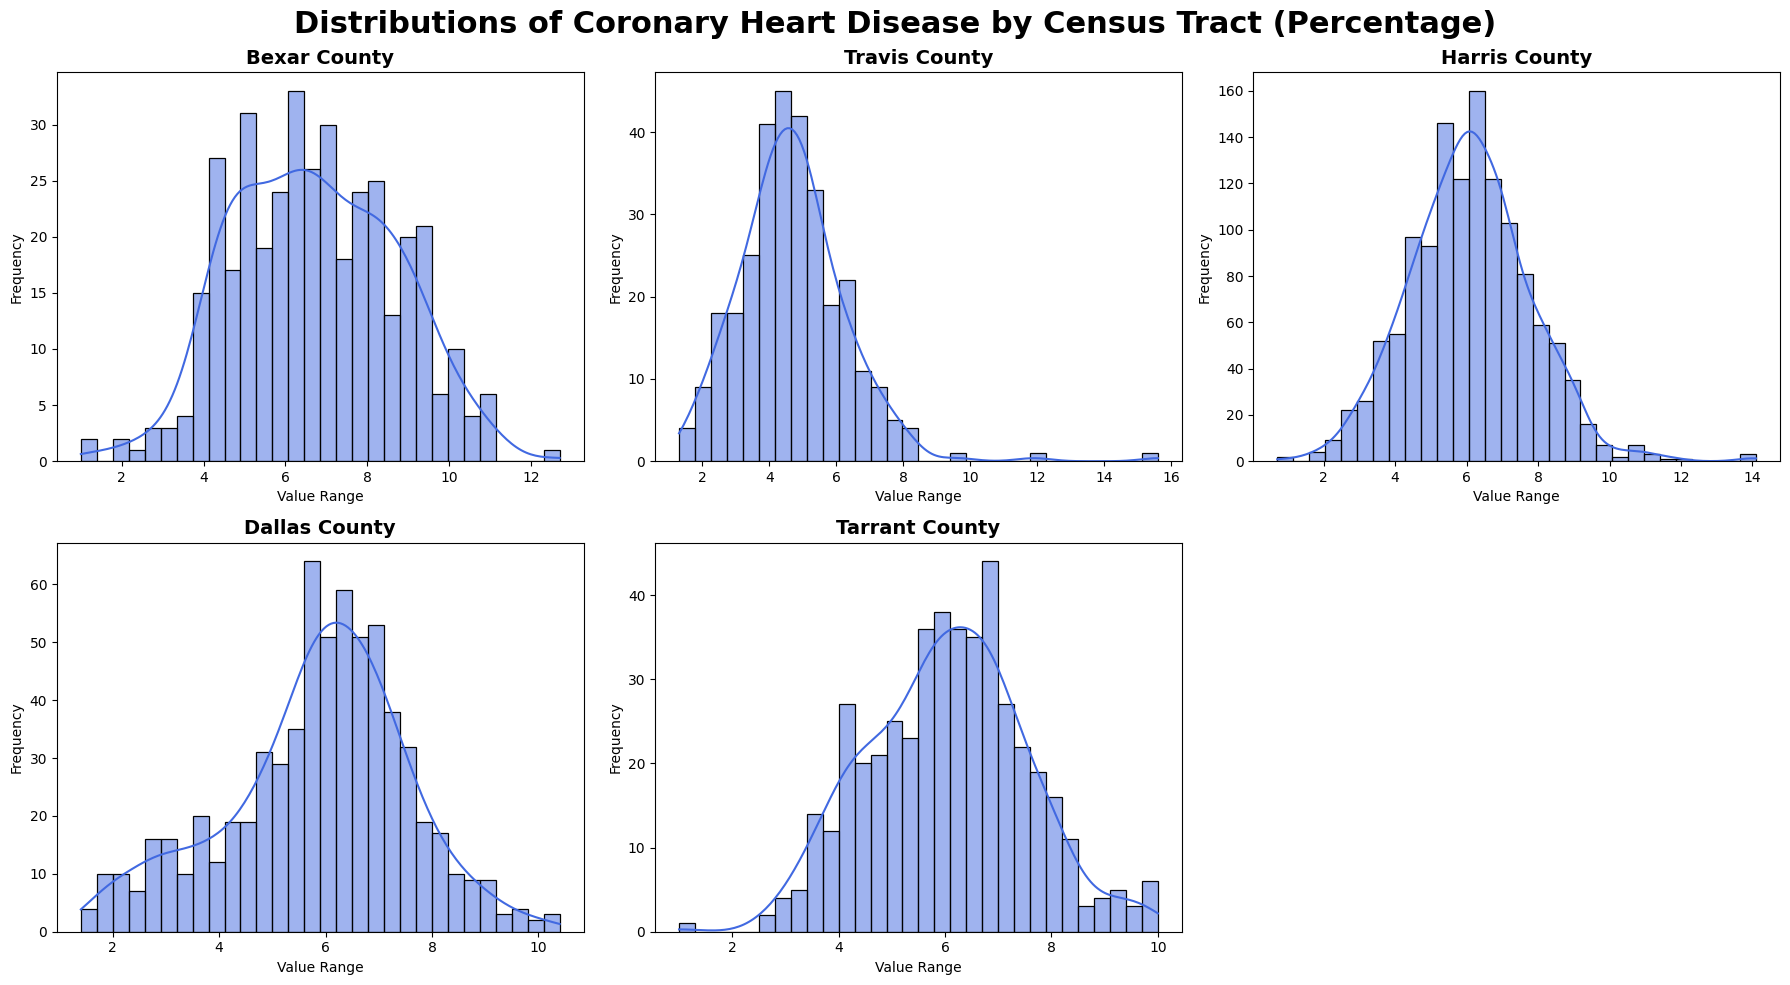

In [56]:
# GENERATING HISTOGRAMS OF DIABETES 
# defining title names and dataframes to loop through 
title_names = [
    "Bexar County",
    "Travis County",
    "Harris County",
    "Dallas County",
    "Tarrant County",
]
dfs = [bexar_gdf, travis_gdf, harris_gdf, 
       dallas_gdf, tarrant_gdf]

# initializing canvas 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten to easily index ax1 through ax6

# looping through and plotting histograms 
for i, df in enumerate(dfs):
    current_ax = axes[i]
    
    # generating histogram
    sns.histplot(
        data=df,
        x="E_CHD",
        kde=True,  # Adds a kernel density estimate line
        color="royalblue",  # Bar color
        bins=30,  # Number of bins
        ax=current_ax,
    )

    # applying axes and histogram titles 
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
    current_ax.set_xlabel("Value Range")
    current_ax.set_ylabel("Frequency")

# removing content in empty axis 
fig.delaxes(axes[5])

# setting overarching title
fig.suptitle(
    "Distributions of Coronary Heart Disease by Census Tract (Percentage)",  
    fontsize=22,  
    fontweight="bold",  
    y=0.98,  
)
# saving and fixing layout 
fig.tight_layout()
plt.savefig("Stat_Modeling/chd_histograms.png", dpi=300, bbox_inches="tight")
plt.show()